# 57 - First 30s Regular UltraTimTrack vs Speckle-Adaptive R

Compare the regular strict Python UltraTimTrack 2-state Kalman path against the same pipeline with the ultrasound speckle-confidence layer adapting the measurement covariance `R_t`.

This notebook uses the first 30 seconds of `UltraTimTrack_test.mp4` and plots `ANG`, `PEN`, and `FL` over time for both variants.

## Design

To keep the comparison clean and fast, the expensive upstream streams are shared:

- KLT fascicle prior: loaded from the strict Python UltraTimTrack result.
- TimTrack alpha stream: loaded from the strict Python UltraTimTrack result.
- Python aponeurosis state lines: loaded from the strict Python UltraTimTrack result.
- Hough peak diagnostics: loaded from Notebook 52 geofeature arrays.
- Speckle/motion confidence: recomputed from the video frames in the fascicle ROI.

Only the final Kalman branch changes: fixed `R` versus adaptive `R_t`.

In [1]:
from __future__ import annotations

import csv
import json
import sys
from dataclasses import replace
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import (
    SpeckleConfidenceConfig,
    combine_confidence_metrics,
    compute_feature_detection_reliability,
    compute_geometry_stability,
    compute_motion_consistency,
    compute_speckle_coherence,
    confidence_to_r_scale,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames
from ultrasound_tracker.ultratimtrack_matlab_2state import (
    MatlabTwoStateKalmanConfig,
    run_matlab_2state_kalman,
)

VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
STRICT_RESULT = ROOT / 'results' / 'strict_ultratimtrack_runs' / 'UltraTimTrack_test' / 'UltraTimTrack_test_strict_results.npz'
GEOFEATURE_ARRAYS = ROOT / 'results' / 'notebook52_correct_video_fixed_emask_timtrack_gate' / 'image_derived_timtrack_geofeatures_arrays.npz'
UTT_EXPORT = Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat')
OUT_DIR = ROOT / 'results' / 'notebook57_first30s_regular_vs_speckle_adaptive_R'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SECONDS = 30.0
FORCE_RECOMPUTE = False

for path in [VIDEO, ROI_PATH, STRICT_RESULT, GEOFEATURE_ARRAYS, UTT_EXPORT]:
    print(path, 'OK' if path.exists() else 'MISSING')

/Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4 OK
/Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json OK
/Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz OK
/Users/grosbedou/PycharmProjects/NDORMS/results/notebook52_correct_video_fixed_emask_timtrack_gate/image_derived_timtrack_geofeatures_arrays.npz OK
/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat OK


In [2]:
def video_info(video_path: Path) -> tuple[float, int, float]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(video_path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    duration = n_frames / fps if fps > 0 else float('nan')
    return fps, n_frames, duration


def segment_length_px(segment: np.ndarray) -> float:
    line = np.asarray(segment, dtype=float).reshape(-1)
    if line.size < 4 or not np.all(np.isfinite(line[:4])):
        return float('nan')
    return float(np.hypot(line[2] - line[0], line[3] - line[1]))


def write_rows(path: Path, rows: list[dict]) -> None:
    if not rows:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def output_rows(name: str, result: dict[str, np.ndarray], time_s: np.ndarray) -> list[dict]:
    fl = result['FL_mm'] if 'FL_mm' in result else result['FL_px']
    rows = []
    for i in range(len(time_s)):
        rows.append({
            'variant': name,
            'frame': int(i),
            'time_s': float(time_s[i]),
            'ANG_deg': float(result['ANG_deg'][i]),
            'PEN_deg': float(result['PEN_deg'][i]),
            'FL': float(fl[i]),
            'FL_px': float(result['FL_px'][i]),
        })
    return rows


def rmse(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return float(np.sqrt(np.nanmean(x * x)))


fps, video_frames, duration_s = video_info(VIDEO)
frame_limit = min(int(round(fps * SECONDS)), video_frames)
print({'fps': fps, 'video_frames': video_frames, 'duration_s': duration_s, 'frame_limit': frame_limit})

{'fps': 33.341, 'video_frames': 2667, 'duration_s': 79.99160193155573, 'frame_limit': 1000}


## Load shared upstream streams

In [3]:
strict = np.load(STRICT_RESULT, allow_pickle=True)
geo = np.load(GEOFEATURE_ARRAYS, allow_pickle=True)

n = min(
    frame_limit,
    len(strict['klt_prior_segments']),
    len(strict['timtrack_alpha_deg']),
    len(strict['sup_apo_lines']),
    len(strict['deep_apo_lines']),
    len(geo['dohough_peak_alphas']),
)
time_s = np.arange(n, dtype=float) / fps

klt_prior = np.asarray(strict['klt_prior_segments'][:n], dtype=float)
timtrack_alpha = np.asarray(strict['timtrack_alpha_deg'][:n], dtype=float)
super_lines = np.asarray(strict['sup_apo_lines'][:n], dtype=float)
deep_lines = np.asarray(strict['deep_apo_lines'][:n], dtype=float)
peak_alphas = np.asarray(geo['dohough_peak_alphas'][:n], dtype=float)
peak_weights = np.asarray(geo['dohough_peak_weights'][:n], dtype=float)
mm_per_pixel = float(np.asarray(strict['mm_per_pixel']).reshape(-1)[0])

print({'n_compare_frames': n, 'compare_seconds': float(time_s[-1]) if n else 0.0, 'mm_per_pixel': mm_per_pixel})

{'n_compare_frames': 1000, 'compare_seconds': 29.963108485048437, 'mm_per_pixel': 0.09021352313167261}


## Compute or load speckle confidence

In [4]:
confidence_npz = OUT_DIR / 'first30s_confidence_metrics.npz'
cfg = SpeckleConfidenceConfig(
    block_size=21,
    stride=24,
    search_radius=8,
    min_texture_variance=5.0,
)

with ROI_PATH.open('r', encoding='utf-8') as f:
    rois = json.load(f)
fascicle_roi = tuple(int(v) for v in rois['fascicle'])

if confidence_npz.exists() and not FORCE_RECOMPUTE:
    conf = dict(np.load(confidence_npz, allow_pickle=True))
    print('Loaded cached confidence:', confidence_npz)
else:
    frames = read_gray_frames(VIDEO, limit=n)
    prior_lengths = np.asarray([segment_length_px(seg) for seg in klt_prior], dtype=float)
    conf = {
        'speckle_zncc': np.full(n, np.nan, dtype=float),
        'speckle_confidence': np.ones(n, dtype=float),
        'forward_backward_error': np.full(n, np.nan, dtype=float),
        'valid_patch_fraction': np.full(n, np.nan, dtype=float),
        'motion_consistency': np.ones(n, dtype=float),
        'motion_spread_px': np.full(n, np.nan, dtype=float),
        'feature_reliability': np.ones(n, dtype=float),
        'geometry_stability': np.ones(n, dtype=float),
        'combined_confidence': np.ones(n, dtype=float),
        'r_scale': np.ones(n, dtype=float),
        'R_t_x_variance': np.full(n, np.nan, dtype=float),
        'R_t_alpha_variance': np.full(n, np.nan, dtype=float),
        'detection_success': np.ones(n, dtype=bool),
    }
    for idx in range(n):
        detection = {
            'alpha': timtrack_alpha[idx],
            'alphas': peak_alphas[idx],
            'weights': peak_weights[idx],
            'detection_success': np.isfinite(timtrack_alpha[idx]),
        }
        feature = compute_feature_detection_reliability(detection, config=cfg)
        geometry = compute_geometry_stability(
            alpha_deg=float(timtrack_alpha[idx]) if np.isfinite(timtrack_alpha[idx]) else None,
            fascicle_length_px=float(prior_lengths[idx]) if np.isfinite(prior_lengths[idx]) else None,
            segment=klt_prior[idx],
            previous_alpha_deg=float(timtrack_alpha[idx - 1]) if idx > 0 and np.isfinite(timtrack_alpha[idx - 1]) else None,
            previous_length_px=float(prior_lengths[idx - 1]) if idx > 0 and np.isfinite(prior_lengths[idx - 1]) else None,
            previous_segment=klt_prior[idx - 1] if idx > 0 else None,
            config=cfg,
        )
        if idx > 0:
            speckle = compute_speckle_coherence(frames[idx - 1], frames[idx], roi=fascicle_roi, config=cfg)
            motion = compute_motion_consistency(
                speckle['points_prev'],
                speckle['points_curr'],
                roi=fascicle_roi,
                config=cfg,
            )
            conf['speckle_zncc'][idx] = float(speckle['speckle_zncc'])
            conf['speckle_confidence'][idx] = float(speckle['speckle_confidence'])
            conf['forward_backward_error'][idx] = float(speckle['forward_backward_error'])
            conf['valid_patch_fraction'][idx] = float(speckle['valid_patch_fraction'])
            conf['motion_consistency'][idx] = float(motion['motion_consistency'])
            conf['motion_spread_px'][idx] = float(motion['motion_spread_px'])
        conf['feature_reliability'][idx] = float(feature['feature_reliability'])
        conf['geometry_stability'][idx] = float(geometry['geometry_stability'])
        conf['detection_success'][idx] = bool(feature['detection_success'])
        combined = combine_confidence_metrics(
            {
                'speckle_confidence': conf['speckle_confidence'][idx],
                'motion_consistency': conf['motion_consistency'][idx],
                'feature_reliability': conf['feature_reliability'][idx],
                'geometry_stability': conf['geometry_stability'][idx],
            },
            config=cfg,
        )
        conf['combined_confidence'][idx] = combined
        conf['r_scale'][idx] = confidence_to_r_scale(combined, cfg)
        if idx and idx % 100 == 0:
            print(f'confidence {idx}/{n}')
    np.savez_compressed(confidence_npz, **conf)
    print('Saved confidence:', confidence_npz)

print({
    'confidence_min': float(np.nanmin(conf['combined_confidence'])),
    'confidence_median': float(np.nanmedian(conf['combined_confidence'])),
    'confidence_max': float(np.nanmax(conf['combined_confidence'])),
    'r_scale_min': float(np.nanmin(conf['r_scale'])),
    'r_scale_max': float(np.nanmax(conf['r_scale'])),
})

confidence 100/1000


confidence 200/1000


confidence 300/1000


confidence 400/1000


confidence 500/1000


confidence 600/1000


confidence 700/1000


confidence 800/1000


confidence 900/1000


Saved confidence: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook57_first30s_regular_vs_speckle_adaptive_R/first30s_confidence_metrics.npz
{'confidence_min': 0.7022469765758953, 'confidence_median': 0.9634298577385785, 'confidence_max': 0.9751327448613126, 'r_scale_min': 0.5764674110798554, 'r_scale_max': 3.6682458994885443}


## Run the two Kalman branches from identical inputs

In [5]:
mat_root = loadmat(UTT_EXPORT, simplify_cells=True)['UTT_numeric_export']
r_values = np.asarray(mat_root.get('R', [3.05529211]), dtype=float).reshape(-1)
base_config = MatlabTwoStateKalmanConfig(
    q_parameter=float(mat_root.get('Q', 0.01)),
    x_measurement_variance=float(mat_root.get('X', 100.0)),
    alpha_measurement_variance=float(r_values[0]),
    n_start_frames=int(mat_root.get('NS', 1)),
    run_smoother=True,
    use_adaptive_R=False,
)
adaptive_config = replace(base_config, use_adaptive_R=True)

regular = run_matlab_2state_kalman(
    klt_prior,
    timtrack_alpha,
    super_lines,
    deep_lines,
    config=base_config,
    mm_per_pixel=mm_per_pixel,
)
adaptive = run_matlab_2state_kalman(
    klt_prior,
    timtrack_alpha,
    super_lines,
    deep_lines,
    config=adaptive_config,
    mm_per_pixel=mm_per_pixel,
    measurement_r_scale=conf['r_scale'],
)

conf['R_t_x_variance'] = adaptive['measurement_R_diag'][:, 0]
conf['R_t_alpha_variance'] = adaptive['measurement_R_diag'][:, 1]

np.savez_compressed(
    OUT_DIR / 'first30s_regular_vs_speckle_adaptive_results.npz',
    time_s=time_s,
    regular_ANG_deg=regular['ANG_deg'],
    regular_PEN_deg=regular['PEN_deg'],
    regular_FL_mm=regular['FL_mm'],
    adaptive_ANG_deg=adaptive['ANG_deg'],
    adaptive_PEN_deg=adaptive['PEN_deg'],
    adaptive_FL_mm=adaptive['FL_mm'],
    **conf,
)

write_rows(OUT_DIR / 'first30s_regular_ultratimtrack.csv', output_rows('regular_fixed_R', regular, time_s))
write_rows(OUT_DIR / 'first30s_speckle_adaptive_ultratimtrack.csv', output_rows('speckle_adaptive_R', adaptive, time_s))
print('Saved outputs to', OUT_DIR)

Saved outputs to /Users/grosbedou/PycharmProjects/NDORMS/results/notebook57_first30s_regular_vs_speckle_adaptive_R


## Summary metrics: adaptive minus regular

In [6]:
metric_rows = []
for name, key, unit in [
    ('ANG', 'ANG_deg', 'deg'),
    ('PEN', 'PEN_deg', 'deg'),
    ('FL', 'FL_mm', 'mm'),
]:
    diff = np.asarray(adaptive[key], dtype=float) - np.asarray(regular[key], dtype=float)
    metric_rows.append({
        'metric': name,
        'unit': unit,
        'adaptive_minus_regular_rmse': rmse(diff),
        'adaptive_minus_regular_mae': float(np.nanmean(np.abs(diff))),
        'adaptive_minus_regular_bias': float(np.nanmean(diff)),
        'adaptive_minus_regular_max_abs': float(np.nanmax(np.abs(diff))),
    })
write_rows(OUT_DIR / 'first30s_adaptive_minus_regular_metrics.csv', metric_rows)
metric_rows

[{'metric': 'ANG',
  'unit': 'deg',
  'adaptive_minus_regular_rmse': 0.17951186425806867,
  'adaptive_minus_regular_mae': 0.14990702982271145,
  'adaptive_minus_regular_bias': 0.14445058977500005,
  'adaptive_minus_regular_max_abs': 0.3490436259199612},
 {'metric': 'PEN',
  'unit': 'deg',
  'adaptive_minus_regular_rmse': 0.17951186425806867,
  'adaptive_minus_regular_mae': 0.14990702982271145,
  'adaptive_minus_regular_bias': 0.14445058977500005,
  'adaptive_minus_regular_max_abs': 0.3490436259199612},
 {'metric': 'FL',
  'unit': 'mm',
  'adaptive_minus_regular_rmse': 0.31148231800456266,
  'adaptive_minus_regular_mae': 0.26102109381524885,
  'adaptive_minus_regular_bias': -0.24826883301950975,
  'adaptive_minus_regular_max_abs': 0.5357692577379325}]

## ANG, PEN, and FL over time

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook57_first30s_regular_vs_speckle_adaptive_R/ANG_PEN_FL_regular_vs_speckle_first30s.png')

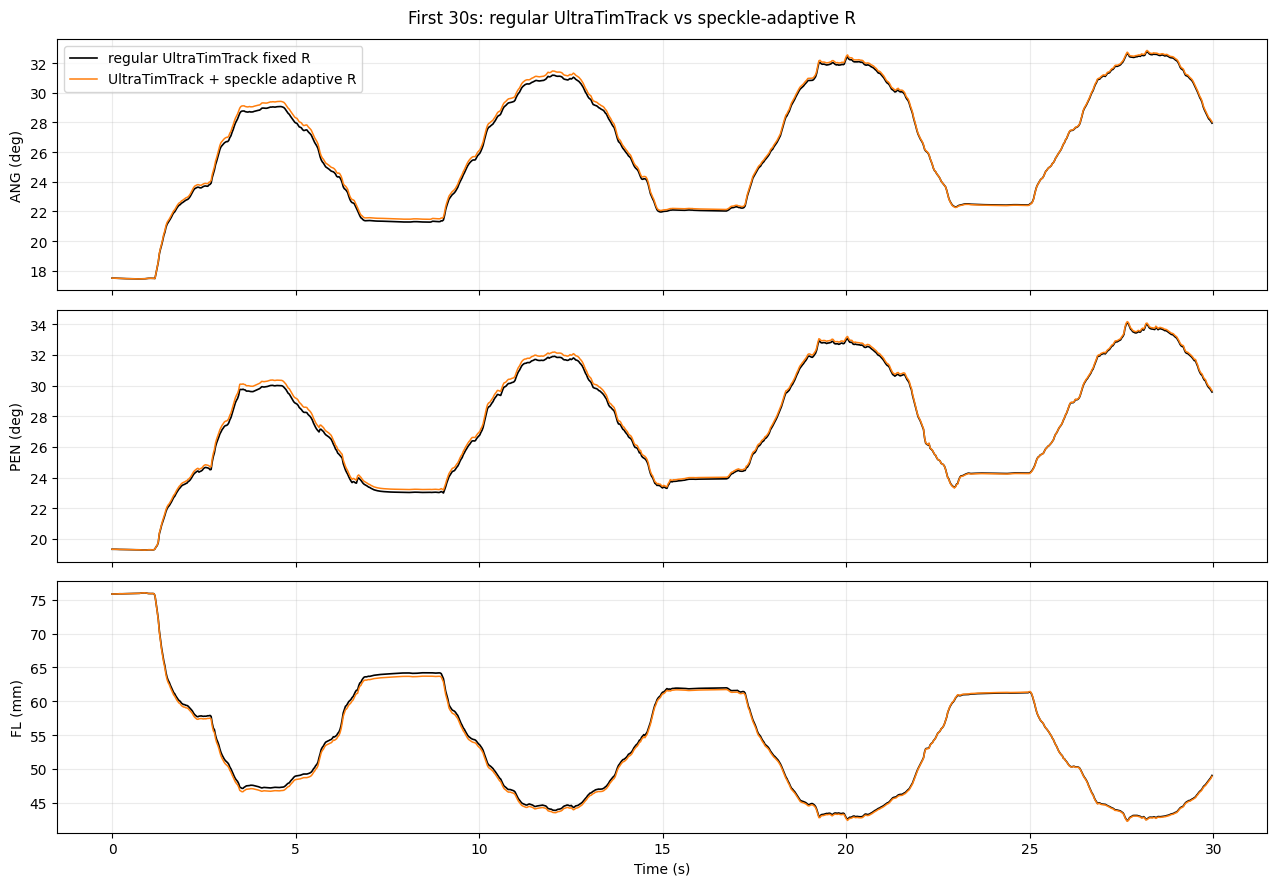

In [7]:
plot_path = OUT_DIR / 'ANG_PEN_FL_regular_vs_speckle_first30s.png'
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
series = [
    ('ANG (deg)', regular['ANG_deg'], adaptive['ANG_deg']),
    ('PEN (deg)', regular['PEN_deg'], adaptive['PEN_deg']),
    ('FL (mm)', regular['FL_mm'], adaptive['FL_mm']),
]
for ax, (label, y_regular, y_adaptive) in zip(axes, series):
    ax.plot(time_s, y_regular, label='regular UltraTimTrack fixed R', color='black', linewidth=1.2)
    ax.plot(time_s, y_adaptive, label='UltraTimTrack + speckle adaptive R', color='tab:orange', linewidth=1.1)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
axes[0].legend(loc='best')
fig.suptitle('First 30s: regular UltraTimTrack vs speckle-adaptive R')
fig.tight_layout()
fig.savefig(plot_path, dpi=170)
plot_path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook57_first30s_regular_vs_speckle_adaptive_R/confidence_and_R_scale_first30s.png')

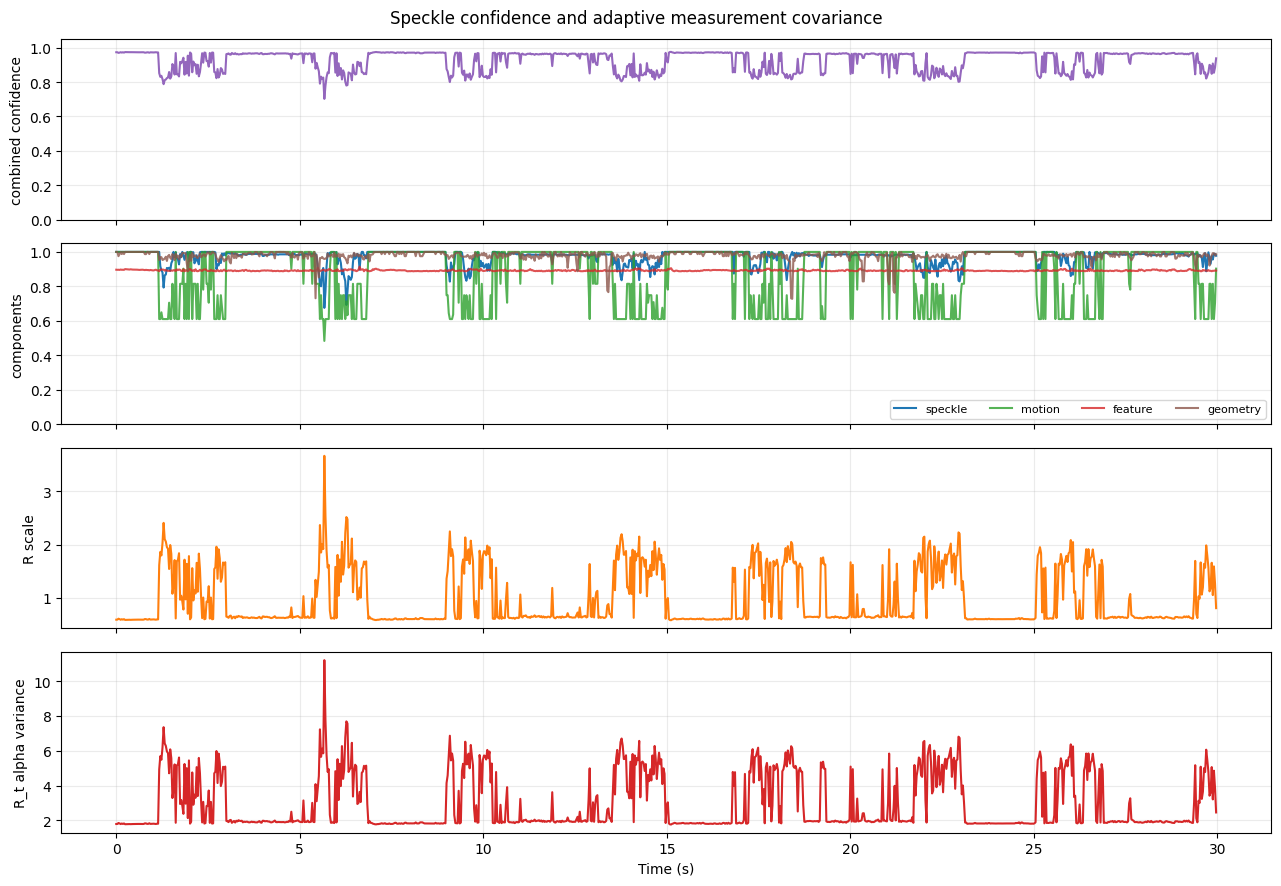

In [8]:
confidence_plot = OUT_DIR / 'confidence_and_R_scale_first30s.png'
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(time_s, conf['combined_confidence'], color='tab:purple')
axes[0].set_ylabel('combined confidence')
axes[0].set_ylim(0, 1.05)
axes[1].plot(time_s, conf['speckle_confidence'], label='speckle', color='tab:blue')
axes[1].plot(time_s, conf['motion_consistency'], label='motion', color='tab:green', alpha=0.8)
axes[1].plot(time_s, conf['feature_reliability'], label='feature', color='tab:red', alpha=0.8)
axes[1].plot(time_s, conf['geometry_stability'], label='geometry', color='tab:brown', alpha=0.8)
axes[1].set_ylabel('components')
axes[1].set_ylim(0, 1.05)
axes[1].legend(ncol=4, fontsize=8, loc='lower right')
axes[2].plot(time_s, conf['r_scale'], color='tab:orange')
axes[2].set_ylabel('R scale')
axes[3].plot(time_s, conf['R_t_alpha_variance'], color='tab:red')
axes[3].set_ylabel('R_t alpha variance')
axes[3].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.suptitle('Speckle confidence and adaptive measurement covariance')
fig.tight_layout()
fig.savefig(confidence_plot, dpi=170)
confidence_plot

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook57_first30s_regular_vs_speckle_adaptive_R/adaptive_minus_regular_errors_first30s.png')

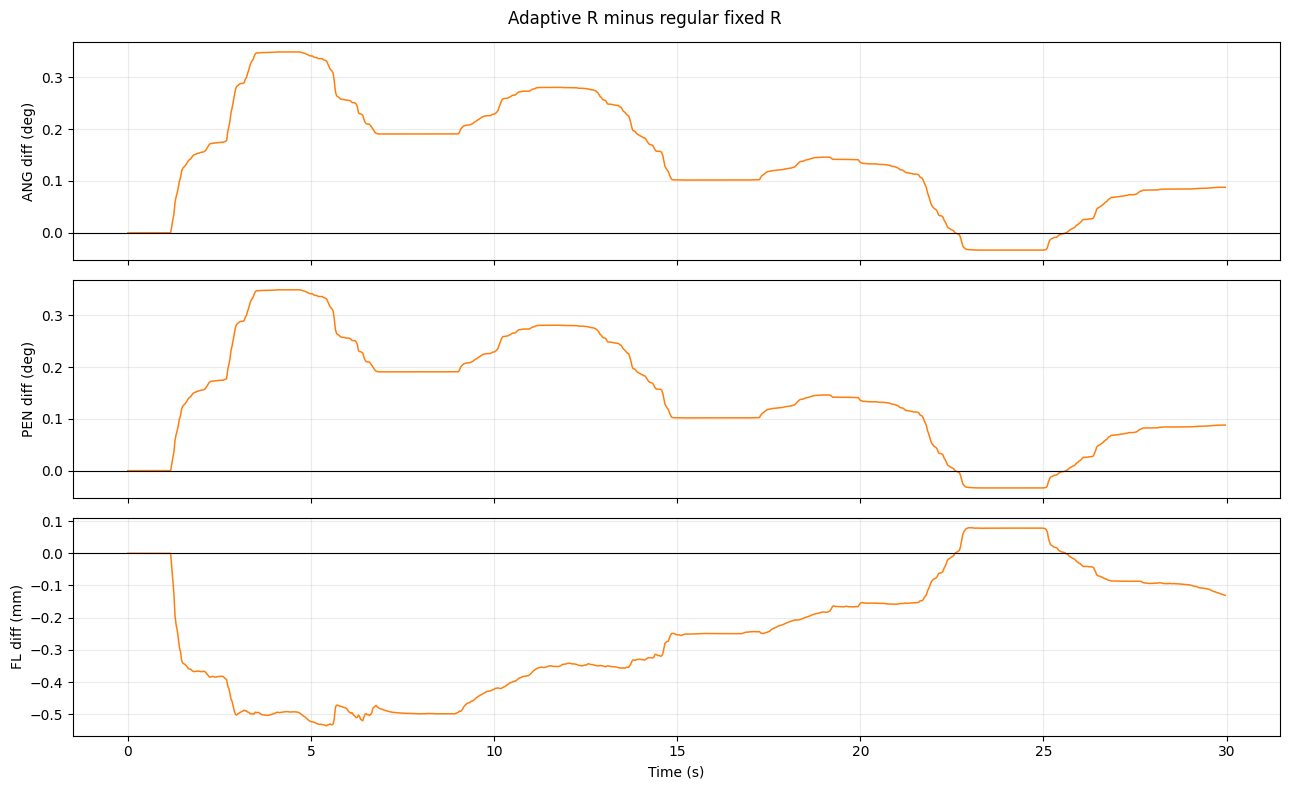

In [9]:
delta_plot = OUT_DIR / 'adaptive_minus_regular_errors_first30s.png'
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (label, key, unit) in zip(axes, [('ANG', 'ANG_deg', 'deg'), ('PEN', 'PEN_deg', 'deg'), ('FL', 'FL_mm', 'mm')]):
    diff = adaptive[key] - regular[key]
    ax.plot(time_s, diff, color='tab:orange', linewidth=1.1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(f'{label} diff ({unit})')
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Adaptive R minus regular fixed R')
fig.tight_layout()
fig.savefig(delta_plot, dpi=170)
delta_plot

## Conclusion

This notebook compares the regular strict UltraTimTrack 2-state branch and the speckle-adaptive `R_t` branch on the first 30 seconds of `UltraTimTrack_test.mp4`. Both branches use the same upstream KLT, TimTrack alpha, and aponeurosis state inputs, so differences in `ANG`, `PEN`, and `FL` come from the adaptive measurement covariance.